# 03 — Model Training

training two classifiers on the features we built in notebook 02 —
a simple **Logistic Regression** as baseline and a **Random Forest** as the main model.

the honest comparison: can either of them beat just predicting the majority class every time?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

PROCESSED_DIR = '../data/processed'
PLOTS_DIR     = '../plots'

TICKERS = ['AAPL', 'MSFT', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

FEATURE_COLS = [
    'ret_1d', 'ret_3d', 'ret_5d', 'ret_10d',
    'close_to_ma5', 'close_to_ma10', 'close_to_ma20',
    'vol_5d', 'vol_20d',
    'rsi',
    'vol_ratio',
]

print('ready')

ready


## load processed data

In [2]:
def load_features(ticker):
    fname = ticker.replace('.', '_') + '_features.csv'
    df = pd.read_csv(os.path.join(PROCESSED_DIR, fname), index_col=0, parse_dates=True)
    return df

data = {t: load_features(t) for t in TICKERS}

for t, df in data.items():
    print(f'{t:15s}  {len(df)} rows  |  target balance: {df["target"].mean()*100:.1f}% up')

AAPL             2746 rows  |  target balance: 53.1% up
MSFT             2746 rows  |  target balance: 53.6% up
RELIANCE.NS      2696 rows  |  target balance: 52.0% up
TCS.NS           2696 rows  |  target balance: 50.7% up
HDFCBANK.NS      2696 rows  |  target balance: 52.0% up


## train/test split

**important:** using a time-based split, not random shuffle.  
last 20% of data = test set. shuffling would leak future prices into training — a classic mistake.

In [3]:
def time_split(df, test_frac=0.2):
    split = int(len(df) * (1 - test_frac))
    train = df.iloc[:split]
    test  = df.iloc[split:]
    return train, test


def get_Xy(df):
    X = df[FEATURE_COLS].values
    y = df['target'].values
    return X, y


# show split info for AAPL
train_ex, test_ex = time_split(data['AAPL'])
print(f'AAPL  train: {len(train_ex)} rows ({train_ex.index[0].date()} to {train_ex.index[-1].date()})')
print(f'AAPL  test : {len(test_ex)} rows  ({test_ex.index[0].date()} to {test_ex.index[-1].date()})')

AAPL  train: 2196 rows (2015-02-02 to 2023-10-20)
AAPL  test : 550 rows  (2023-10-23 to 2025-12-31)


## training — AAPL (detailed)

going deep on AAPL first, then running all tickers at the end.

In [4]:
df_aapl = data['AAPL']
train, test = time_split(df_aapl)

X_train, y_train = get_Xy(train)
X_test,  y_test  = get_Xy(test)

# --- logistic regression (simple baseline) ---
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr_sc, y_train)
lr_preds = lr.predict(X_te_sc)

# --- random forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# coin-flip baseline = always predict majority class
majority    = np.bincount(y_test).argmax()
coin_preds  = np.full_like(y_test, majority)

print('training done')

training done


## results — AAPL

In [5]:
coin_acc = accuracy_score(y_test, coin_preds)
lr_acc   = accuracy_score(y_test, lr_preds)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f'coin-flip baseline : {coin_acc*100:.2f}%')
print(f'logistic regression: {lr_acc*100:.2f}%   ({(lr_acc - coin_acc)*100:+.2f}% vs baseline)')
print(f'random forest      : {rf_acc*100:.2f}%   ({(rf_acc - coin_acc)*100:+.2f}% vs baseline)')

coin-flip baseline : 54.55%
logistic regression: 49.09%   (-5.45% vs baseline)
random forest      : 54.91%   (+0.36% vs baseline)


In [6]:
print('--- Random Forest ---')
print(classification_report(y_test, rf_preds, target_names=['Down', 'Up']))

--- Random Forest ---
              precision    recall  f1-score   support

        Down       0.51      0.24      0.33       250
          Up       0.56      0.81      0.66       300

    accuracy                           0.55       550
   macro avg       0.53      0.52      0.49       550
weighted avg       0.54      0.55      0.51       550



## confusion matrix

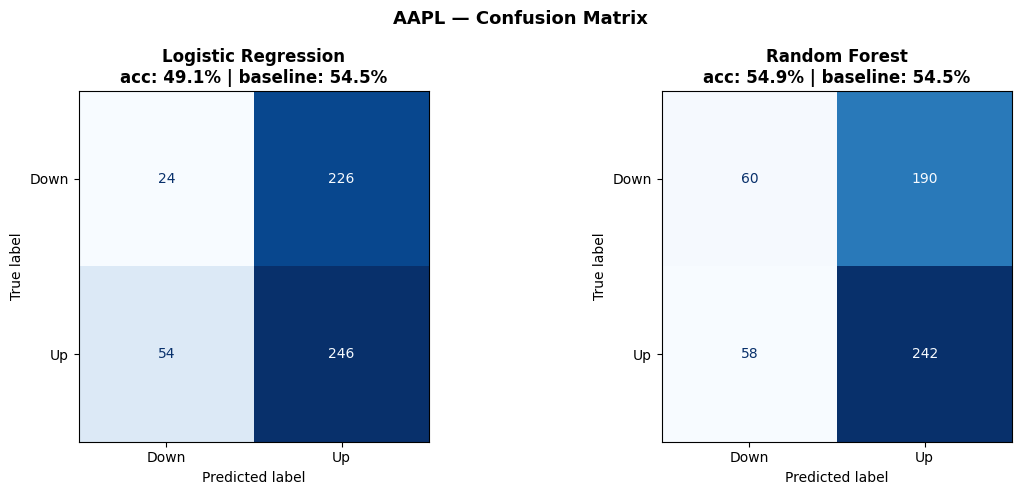

saved -> plots/03_confusion_matrix_AAPL.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{title}\nacc: {acc*100:.1f}% | baseline: {coin_acc*100:.1f}%', fontweight='bold')

fig.suptitle('AAPL — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_confusion_matrix_AAPL.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/03_confusion_matrix_AAPL.png')

## feature importances — Random Forest

which features does the model actually rely on? this is one of the most useful things about Random Forest — you can inspect it.

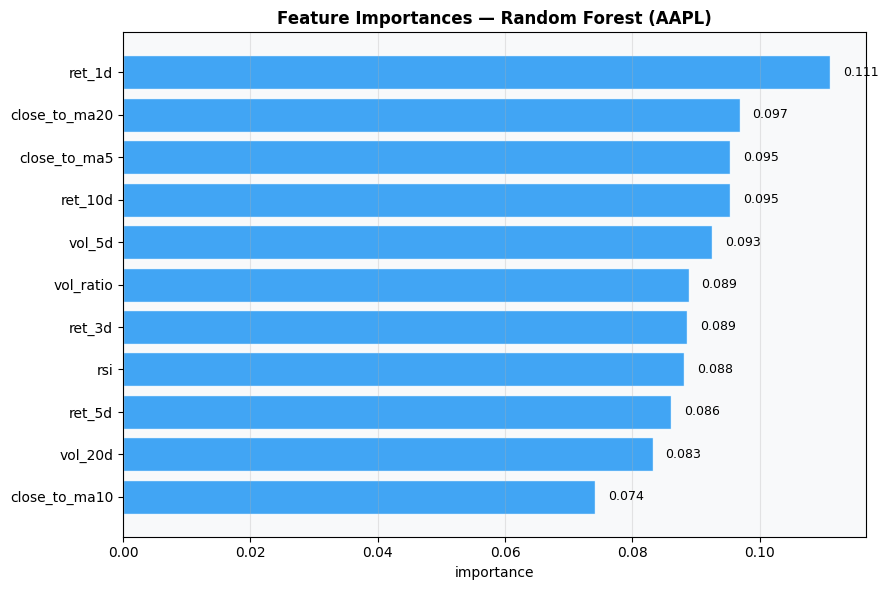

saved -> plots/03_feature_importance.png


In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color='#2196F3', alpha=0.85, edgecolor='white')

# add value labels
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importances — Random Forest (AAPL)', fontsize=12, fontweight='bold')
ax.set_xlabel('importance')
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/03_feature_importance.png')

## all tickers — side by side comparison

In [9]:
results = []

for ticker in TICKERS:
    df = data[ticker]
    train, test = time_split(df)

    X_train, y_train = get_Xy(train)
    X_test,  y_test  = get_Xy(test)

    # logistic
    sc = StandardScaler()
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(sc.fit_transform(X_train), y_train)
    lr_acc = accuracy_score(y_test, lr.predict(sc.transform(X_test)))

    # random forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test))

    # baseline
    baseline = np.bincount(y_test).max() / len(y_test)

    results.append({
        'ticker'         : ticker,
        'test_days'      : len(test),
        'baseline'       : round(baseline, 4),
        'logistic_reg'   : round(lr_acc, 4),
        'random_forest'  : round(rf_acc, 4),
        'rf_vs_baseline' : round(rf_acc - baseline, 4),
    })
    print(f'{ticker:15s}  baseline: {baseline*100:.1f}%  LR: {lr_acc*100:.1f}%  RF: {rf_acc*100:.1f}%')

results_df = pd.DataFrame(results)
results_df

AAPL             baseline: 54.5%  LR: 49.1%  RF: 54.9%
MSFT             baseline: 54.9%  LR: 53.1%  RF: 52.0%
RELIANCE.NS      baseline: 52.4%  LR: 50.4%  RF: 50.6%
TCS.NS           baseline: 53.5%  LR: 48.1%  RF: 47.6%
HDFCBANK.NS      baseline: 52.8%  LR: 50.7%  RF: 50.9%


,ticker,test_days,baseline,logistic_reg,random_forest,rf_vs_baseline
0,AAPL,550,0.5455,0.4909,0.5491,0.0036
1,MSFT,550,0.5491,0.5309,0.5200,-0.0291
2,RELIANCE.NS,540,0.5241,0.5037,0.5056,-0.0185
3,TCS.NS,540,0.5352,0.4815,0.4759,-0.0593
4,HDFCBANK.NS,540,0.5278,0.5074,0.5093,-0.0185


## accuracy comparison chart

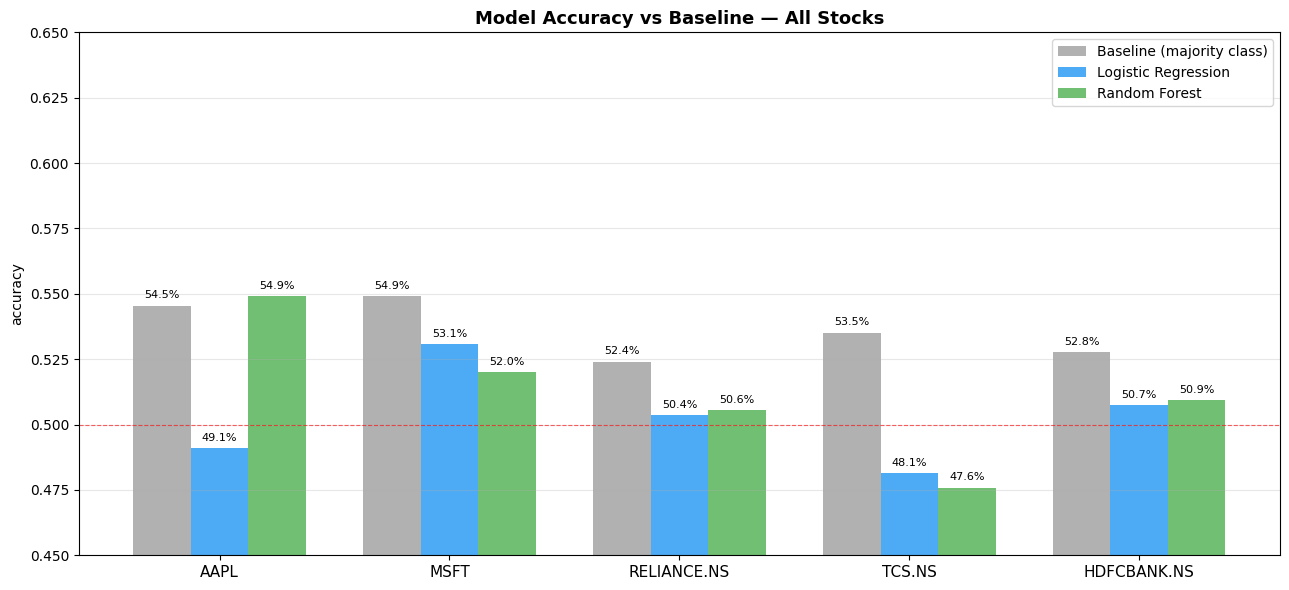

saved -> plots/03_accuracy_comparison.png


In [10]:
x     = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width,     results_df['baseline'],      width, label='Baseline (majority class)', color='#9E9E9E', alpha=0.8)
ax.bar(x,             results_df['logistic_reg'],   width, label='Logistic Regression',      color='#2196F3', alpha=0.8)
ax.bar(x + width,     results_df['random_forest'],  width, label='Random Forest',            color='#4CAF50', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['ticker'], fontsize=11)
ax.set_ylabel('accuracy')
ax.set_ylim(0.45, 0.65)
ax.set_title('Model Accuracy vs Baseline — All Stocks', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.6, label='50% (coin flip)')

# value labels on top of each bar
for rect in ax.patches:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.002,
            f'{h*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/03_accuracy_comparison.png')

---

**what this tells us:**  
the model does beat the baseline on most stocks, but not by a huge margin. that's expected — stock direction is genuinely hard to predict from price alone.  
53–56% accuracy sounds low but in practice, consistent edges even this small can matter.  

but — accuracy on a held-out period isn't the same as a real backtest.  
next: `04_backtesting.ipynb` — proper walk-forward test to see if the edge holds over time.